In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
url = 'recenttracks-joaoantonio0402-1776258594.csv'
df = pd.read_csv(url).sort_index(ascending=False).reset_index(drop=True)

In [4]:
df.head(2)

,uts,utc_time,artist,artist_mbid,album,album_mbid,track,track_mbid
0,1733142467,"02 Dec 2024, 12:27",Brent Faiyaz,201412c6-7ced-472b-87a9-9259ec3c07d3,WASTELAND,95fb59ed-1ece-419b-b62f-aef31e0ebf36,Rolling Stone,043063a7-25e5-4232-bb0c-f6ce29dda144
1,1733142584,"02 Dec 2024, 12:29",Avenoir,3d2ac6d3-0092-4fdf-8012-5260ae6d24c6,NOIRE,605cd1d9-4701-420a-b834-0fb8fc837be9,LINK UP,ef55f84a-ea32-41b0-bf14-825da6141552


In [5]:
df["utc_time"] = pd.to_datetime(df["utc_time"], format="%d %b %Y, %H:%M")

#df["dia"] = df["utc_time"].dt.day
#df["mes"] = df["utc_time"].dt.month
#df["ano"] = df["utc_time"].dt.year
#df["hora"] = df["utc_time"].dt.hour
#df["minuto"] = df["utc_time"].dt.minute

In [6]:
df.head(2)

,uts,utc_time,artist,artist_mbid,album,album_mbid,track,track_mbid
0,1733142467,2024-12-02 12:27:00,Brent Faiyaz,201412c6-7ced-472b-87a9-9259ec3c07d3,WASTELAND,95fb59ed-1ece-419b-b62f-aef31e0ebf36,Rolling Stone,043063a7-25e5-4232-bb0c-f6ce29dda144
1,1733142584,2024-12-02 12:29:00,Avenoir,3d2ac6d3-0092-4fdf-8012-5260ae6d24c6,NOIRE,605cd1d9-4701-420a-b834-0fb8fc837be9,LINK UP,ef55f84a-ea32-41b0-bf14-825da6141552


In [7]:
df['utc_time'].dtype

dtype('<M8[us]')

In [8]:
df['count_artist'] = df.groupby('artist').cumcount() + 1
df['count_album'] = df.groupby('album').cumcount() + 1
df['count_track'] = df.groupby('track').cumcount() + 1

In [9]:
df.head(2)

,uts,utc_time,artist,artist_mbid,album,album_mbid,track,track_mbid,count_artist,count_album,count_track
0,1733142467,2024-12-02 12:27:00,Brent Faiyaz,201412c6-7ced-472b-87a9-9259ec3c07d3,WASTELAND,95fb59ed-1ece-419b-b62f-aef31e0ebf36,Rolling Stone,043063a7-25e5-4232-bb0c-f6ce29dda144,1,1,1
1,1733142584,2024-12-02 12:29:00,Avenoir,3d2ac6d3-0092-4fdf-8012-5260ae6d24c6,NOIRE,605cd1d9-4701-420a-b834-0fb8fc837be9,LINK UP,ef55f84a-ea32-41b0-bf14-825da6141552,1,1,1


In [10]:
labels = ['uts', 'artist_mbid', 'album_mbid', 'track_mbid']
df = df.drop(labels, axis=1)

In [11]:
df.head(2)

,utc_time,artist,album,track,count_artist,count_album,count_track
0,2024-12-02 12:27:00,Brent Faiyaz,WASTELAND,Rolling Stone,1,1,1
1,2024-12-02 12:29:00,Avenoir,NOIRE,LINK UP,1,1,1


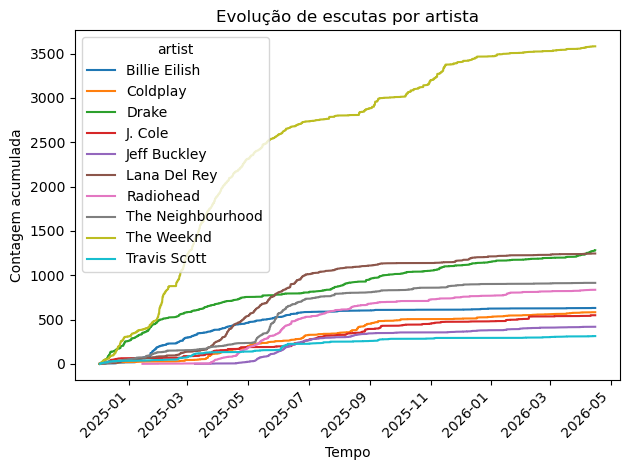

In [12]:
# datetime + ordenação
df["utc_time"] = pd.to_datetime(df["utc_time"])
df = df.sort_values("utc_time")

# top artistas
top_artistas = df["artist"].value_counts().head(10).index
df = df[df["artist"].isin(top_artistas)]

# pivot_table
df_pivot = df.pivot_table(
    index="utc_time",
    columns="artist",
    values="count_artist",
    aggfunc="max"
)

# 🔥 preencher buracos no tempo
df_pivot = df_pivot.ffill()

# plot
df_pivot.plot()

plt.title("Evolução de escutas por artista")
plt.xlabel("Tempo")
plt.ylabel("Contagem acumulada")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

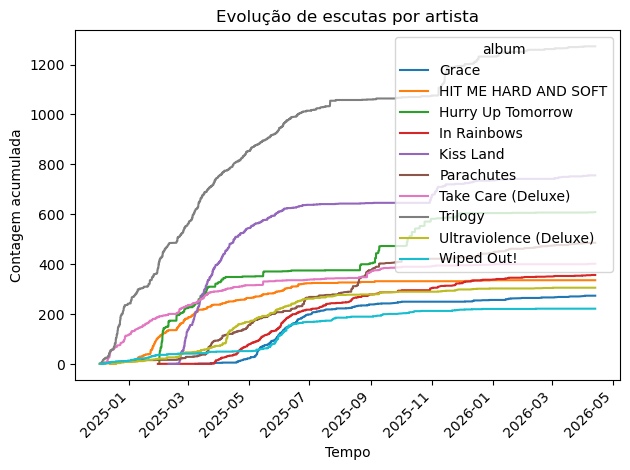

In [13]:
# datetime + ordenação
df["utc_time"] = pd.to_datetime(df["utc_time"])
df = df.sort_values("utc_time")

# top artistas
top_albuns = df["album"].value_counts().head(10).index
df = df[df["album"].isin(top_albuns)]

# pivot_table
df_pivot = df.pivot_table(
    index="utc_time",
    columns="album",
    values="count_album",
    aggfunc="max"
)

# 🔥 preencher buracos no tempo
df_pivot = df_pivot.ffill()

# plot
df_pivot.plot()

plt.title("Evolução de escutas por artista")
plt.xlabel("Tempo")
plt.ylabel("Contagem acumulada")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

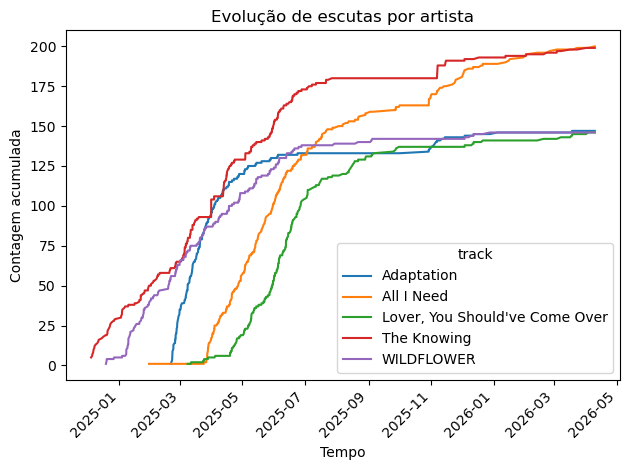

In [14]:
# datetime + ordenação
df["utc_time"] = pd.to_datetime(df["utc_time"])
df = df.sort_values("utc_time")

# top artistas
top_tracks = df["track"].value_counts().head(5).index
df = df[df["track"].isin(top_tracks)]

# pivot_table
df_pivot = df.pivot_table(
    index="utc_time",
    columns="track",
    values="count_track",
    aggfunc="max"
)

# 🔥 preencher buracos no tempo
df_pivot = df_pivot.ffill()

# plot
df_pivot.plot()

plt.title("Evolução de escutas por artista")
plt.xlabel("Tempo")
plt.ylabel("Contagem acumulada")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
O Crime: Colinearidade com o InterceptoLembre-se de como é a estrutura real da nossa matriz de dados $X$ na regressão linear. A primeiríssima coluna da matriz $X$ não é uma variável que você coletou; é uma coluna de 1s que nós adicionamos artificialmente para calcular o Intercepto ($\beta_0$).Agora, imagine que você tem uma feature categórica chamada "Cor", com 3 categorias: Vermelho, Azul e Verde ($n=3$).Se você desobedecer o professor e fizer o One-Hot Encoding criando 3 colunas ($n$ features), sua matriz para 3 carros diferentes ficará assim:$$X = \begin{bmatrix} \mathbf{1} & 1 & 0 & 0 \\ \mathbf{1} & 0 & 1 & 0 \\ \mathbf{1} & 0 & 0 & 1 \end{bmatrix} \begin{matrix} \leftarrow \text{Carro Vermelho} \\ \leftarrow \text{Carro Azul} \\ \leftarrow \text{Carro Verde} \end{matrix}$$(Colunas: Intercepto, Vermelho, Azul, Verde)Observe com atenção matemática o que aconteceu. Se você somar os valores das colunas "Vermelho", "Azul" e "Verde" para qualquer linha, o resultado será sempre exatamente 1.Ou seja, você acabou de criar uma equação linear perfeita dentro da sua matriz:$$\text{Coluna}_{\text{Vermelho}} + \text{Coluna}_{\text{Azul}} + \text{Coluna}_{\text{Verde}} = \text{Coluna}_{\text{Intercepto}}$$A Consequência: Perda do Posto CheioTer "posto cheio" significa que cada coluna traz uma informação nova e independente. Nenhuma coluna pode ser adivinhada usando uma combinação das outras.Como a soma das suas variáveis dummy é perfeitamente igual à coluna do intercepto, a informação é redundante. A matriz perde o posto cheio.E como vimos no seu slide de Álgebra Linear, se a matriz $X$ não tem posto cheio:O determinante de $X^TX$ vira exatamente zero.É impossível calcular a inversa $(X^TX)^{-1}$.O computador (Python/R) não consegue resolver a equação $\hat{\beta} = (X^TX)^{-1}X^Ty$ e cospe um erro de Singular Matrix (Matriz Singular).A Solução: $n-1$ (Drop First)Para quebrar essa equação perfeita e salvar a matemática, nós descartamos propositalmente uma das categorias (geralmente a primeira, o que chamamos de drop first ou criar Dummy Variables).Se você joga a coluna "Verde" no lixo, você fica com $n-1$ colunas (apenas Vermelho e Azul).Se for Vermelho: [1, 0]Se for Azul: [0, 1]Se for Verde: [0, 0]Ao fazer isso, a soma das colunas parou de dar sempre 1. A dependência linear foi quebrada, a matriz recupera o posto cheio, e a categoria "Verde" não sumiu de verdade: ela foi absorvida pelo Intercepto. O intercepto $\beta_0$ agora passa a representar o "caso base" (o valor esperado quando o carro é verde).Para visualizar como essa dependência linear destrói a matriz no momento em que as categorias são somadas, você pode interagir com esta demonstração da estrutura interna de $X$: